# 262: combiner B, best of n alphabet-ksize pairs

Input: the table [notebook 260](260_kmerseek_region_table.ipynb) writes, one row per human
query, target species, merged region and alphabet-ksize pair (one reduced amino-acid
alphabet at one k-mer size; the column is `arm`). A merged region is the stretch of the
query that overlapping kmerseek calls cover, joined across every pair.
[Notebook 261](261_combiner_a_intersection_panel.ipynb) is combiner A, which calls a region
only when every pair in a panel calls it. This notebook is the opposite end.

**Combiner B.** Every merged region any pair called is a candidate, ranked by the best
score any pair gave it. Three scores, kept apart:

| score | definition | better |
|---|---|---|
| lowest E-value, raw | min over pairs of `region_evalue` | lower |
| lowest E-value, corrected | `n_arms_tried` x the raw value | lower |
| highest mean IDF | max over pairs of `region_mean_idf` | higher |

`region_evalue` is kmerseek's E-value: how many regions scoring at least this well a
search of the same database would find by chance. `region_mean_idf` is the mean rarity of
one shared k-mer in the region (the sum over its k-mers of ln(targets / targets holding
the k-mer), divided by the number of k-mers).

Taking the lowest of n E-values gives n chances to get a low one by luck. The corrected
value multiplies by `n_arms_tried`, the number of pairs whose search was run on that query
and target species, whether or not they called anything there. It is the score used for
ranking and for the threshold; the raw value is kept beside it to show the difference.

**Truth**, as in notebooks 260 and 261. A merged region is a true call when at least half
of it lies inside one feature of the truth set. Two truth sets: Swiss-Prot features
(DOMAIN, REGION, TRANSMEM, REPEAT, BINDING and the rest, the key
[notebook 231](231_swissprot_composition_controls.ipynb) scored on) and Pfam domains.

- Precision = true calls / calls, over calls on queries that have at least one feature in
  that truth set. Higher is fewer false calls.
- Recall = truth features with at least one call landed inside them / all truth features
  on the split's queries, counted once per target species searched. Higher is more found.

**Procedure, fixed before running.**
1. Tune split. For each score, draw precision against recall in both truth sets, with two
   references: the single pair with the highest tune average precision for that score and
   truth set, and notebook 231's Kyte-Doolittle scan. The scan reads only the query: a
   19-residue window whose mean hydropathy is above 1.6 is called a transmembrane segment,
   scored by its best window mean. It searches nothing, so kmerseek has to beat it.
2. Threshold. For each score and truth set, the loosest threshold at which tune precision
   is still at least 0.5. Notebook 261 chose on Swiss-Prot; the threshold carried forward
   is the corrected E-value on Swiss-Prot, or on Pfam if no Swiss-Prot threshold reaches
   0.5. Saved to `262_best_of_n_threshold.yaml`.
3. Shuffled queries (each human protein with its residues shuffled in pairs, so it has no
   homolog and every call on it is false): count the regions passing the frozen threshold,
   per shuffled query and target species. That is the false-call rate.
4. Report the frozen threshold on test. No choice is made on test.
5. Test queries with two or more Pfam domains: domains landed per query, as in notebook 261,
   for best of n, combiner A's frozen panel, the single best pair, and phmmer.
6. Which pair gives the winning score, by Swiss-Prot feature type and by region length.

The split is by query: `tune` or `test` by the first byte of SHA-1 of the accession
(notebook 260). A shuffled query goes to its source protein's half.

## Which data this execution reads

The same files as [notebook 261](261_combiner_a_intersection_panel.ipynb). The kmerseek 0.4
midi-plus run with extension (`make run-midi-plus-0.4-extend`, PR #88) and its
shuffled-query twin (`M04_RUN=decoy`) have not run. The table has four pairs, all one
alphabet at one k: hp_pbotc_1st_ed2 at k=19 against zebrafish, at extension penalties 1.63
and 2, each searched with the built-in alphabet and with the same two-letter partition
given as already-encoded sequences (`encoded_`). hp_pbotc_1st_ed2 puts `ACFGILMVWY` in the
hydrophobic class and `DEHKNPQRST` in the polar class. The fly protein20 k=7 file has no
E-values and contributes nothing.

What that means here:
- Every zebrafish region has `n_arms_tried` = 4, so the corrected E-value is the raw one
  times 4 for every region. The two E-value rankings are the same order; only the
  threshold's number differs. The correction matters once queries differ in how many
  pairs searched them, or once thresholds are compared across runs with different n.
- The four pairs are near-copies of one search, so "the best of four" is close to "one".
- No shuffled-query table exists, so step 3 has no number yet.
- Notebook 260 kept only calls with `region_evalue` < 10. Every region here has raw
  E-value below 10 and corrected below 40, and the mean-IDF ranking is over those regions
  only.

Scores are taken over every call in the region (all target proteins), re-read from
notebook 260's `reduced/` files and re-merged with notebook 260's merge; the cell below
checks the re-merge gives the table's merged regions.

phmmer (HMMER3 single-sequence search): the midi-plus region benchmark run (1-2 Sept 2026),
the same 998 human queries against the zebrafish proteome, per-domain hits with their
i-Evalue, query span 1-based inclusive.

/Users/olga/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet: 6_140 rows, sha256 c936f3884dbbb25f
calls re-read from /Users/olga/data/qfo-pfam-region-midi-plus-0.4/260_region_table/reduced: 318_268; re-merge matches the table's 1_713 merged regions
pairs searched per target species (n_arms_tried):
shape: (2, 3)
┌───────────┬──────────────┬───────────────────────────────────────────────────────────────────────────────────┐
│ species   ┆ n_arms_tried ┆ arms_tried                                                                        │
│ ---       ┆ ---          ┆ ---                                                                               │
│ str       ┆ u32          ┆ list[str]                                                                         │
╞═══════════╪══════════════╪═══════════════════════════════════════════════════════════════════════════════════╡
│ zebrafish ┆ 4            ┆ ["encoded_hp_pbotc_1st_ed2_k19_ext1.63", "encoded_hp_pbotc_1st_ed2_k1

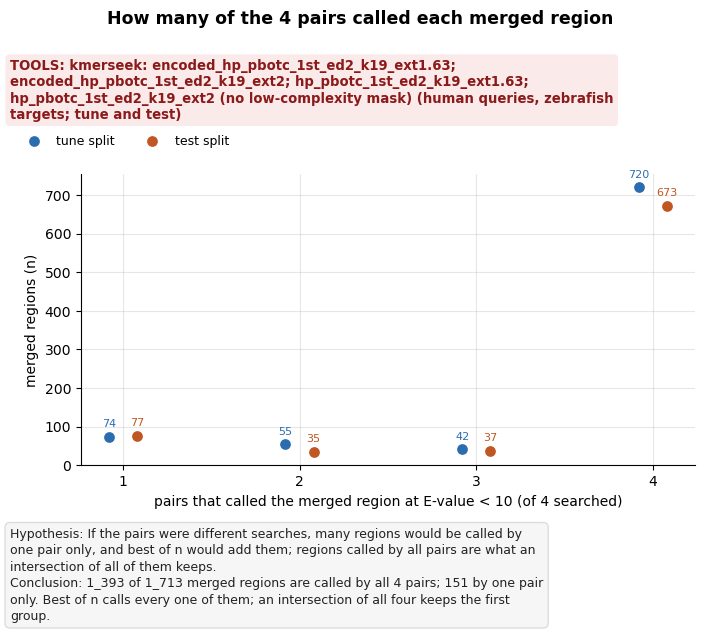

In [1]:
import hashlib
import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from matplotlib.lines import Line2D

sys.path.insert(0, str(Path.cwd()))
import mhc_region_utils as mu
import region_combiner_261 as rc
import region_combiner_262 as rb
import region_table_260 as rt

pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_width_chars(240)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(80)

BASE = Path.home() / "data" / "qfo-pfam-region-midi-plus-0.4" / "260_region_table"
TABLE = BASE / "region_table.parquet"
TRUTH_PAIRS = BASE / "region_table_truth_pairs.parquet"
REDUCED = BASE / "reduced"
DECOY_REDUCED = BASE / "reduced_decoy"
PFAM_TRUTH = mu.MIDI_DIR / "truth" / "human_domain_truth.parquet"
SWISSPROT_TRUTH = mu.MIDI_DIR / "truth_swissprot" / "human_swissprot_truth.parquet"
QUERY_MAP = mu.MIDI_DIR / "query_gene_map.parquet"
PHMMER_DIR = mu.MIDI_DIR / "regions" / "hmmer3_phmmer"
PANEL_A_YAML = Path.cwd() / "261_intersection_panel.yaml"
OUT_YAML = Path.cwd() / "262_best_of_n_threshold.yaml"
FIG = Path.cwd().parent / "figures"

def sha256(p: Path) -> str:
    return hashlib.sha256(p.read_bytes()).hexdigest()

table = pl.read_parquet(TABLE)
truth_pairs = pl.read_parquet(TRUTH_PAIRS)
truth = rt.load_truth(PFAM_TRUTH, SWISSPROT_TRUTH)
summary = pl.read_parquet(REDUCED / "reduce_summary.parquet")
tried = rb.arms_tried(summary)
calls = rb.merged_calls(REDUCED, table)  # raises if the re-merge differs from the table
scores = rb.attach_truth(rb.region_scores(calls, tried), table)
queries = pl.read_parquet(QUERY_MAP).select("accession", "hgnc_symbol").with_columns(
    split=rt.query_split(pl.col("accession")))
SPECIES = sorted(scores["species"].unique().to_list())
ARMS = sorted(calls["arm"].unique().to_list())

print(f"{TABLE}: {table.height:_} rows, sha256 {sha256(TABLE)[:16]}")
print(f"calls re-read from {REDUCED}: {calls.height:_}; re-merge matches the table's "
      f"{scores.height:_} merged regions")
print("pairs searched per target species (n_arms_tried):")
print(tried)
print(f"pairs with calls: {ARMS}")
print(f"species with calls: {SPECIES}")
print("merged regions by split:", scores.group_by("split").len().sort("split").to_dicts())
print("queries by split (all 998):", queries.group_by("split").len().sort("split").to_dicts())
print(f"shuffled-query reduced files: {'present' if DECOY_REDUCED.exists() else 'absent, ' + str(DECOY_REDUCED)}")

fired = (scores.group_by("split", "n_arms_fired").len("n_regions").sort("split", "n_arms_fired"))
print(fired.pivot(on="split", index="n_arms_fired", values="n_regions").sort("n_arms_fired"))
SPLIT_C = {"tune": "#2B6CB0", "test": "#C05621"}
fig, ax = plt.subplots(figsize=(7, 4))
for off, s in ((-0.08, "tune"), (0.08, "test")):
    d = fired.filter(pl.col("split") == s)
    ax.scatter(d["n_arms_fired"] + off, d["n_regions"], color=SPLIT_C[s], s=45, label=f"{s} split", zorder=3)
    for x, yv in zip(d["n_arms_fired"], d["n_regions"]):
        ax.annotate(f"{yv:_}", (x + off, yv), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8,
                    color=SPLIT_C[s])
ax.set_xticks(range(1, len(ARMS) + 1))
ax.set_xlabel(f"pairs that called the merged region at E-value < 10 (of {len(ARMS)} searched)")
ax.set_ylabel("merged regions (n)")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
h, l = ax.get_legend_handles_labels()
fig.legend(h, l, loc="upper left", bbox_to_anchor=(0.0, 1.0), ncol=2, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.92))
n_all = scores.filter(pl.col("n_arms_fired") == len(ARMS)).height
mu.finish_figure(
    fig, FIG / "262_best_of_n_regions_by_pairs_that_called_them_zebrafish.png",
    tools=mu.tools_text(kmerseek=ARMS, lc=False, note="human queries, zebrafish targets; tune and test"),
    title="How many of the 4 pairs called each merged region",
    hypothesis="If the pairs were different searches, many regions would be called by one pair "
               "only, and best of n would add them; regions called by all pairs are what an "
               "intersection of all of them keeps.",
    conclusion=(f"{n_all:_} of {scores.height:_} merged regions are called by all {len(ARMS)} pairs; "
                f"{scores.filter(pl.col('n_arms_fired') == 1).height:_} by one pair only. Best of n "
                "calls every one of them; an intersection of all four keeps the first group."),
    layout=False,
)

## The scores, raw and corrected, region by region

One row per merged region, with the three scores, which pair gave the best E-value and the
best IDF (every pair when tied), and how many pairs called it (`n_arms_fired`) against how
many were run (`n_arms_tried`). Below, the regions called at a few E-value cuts by the raw
and by the corrected value: the difference between those two columns is what the
correction removes.

shape: (15, 14)
┌─────────────┬───────────┬───────────┬──────────────────┬──────────────┬────────────┬───────┬──────────────┬──────────────┬────────────┬────────────────────────────┬──────────────┬─────────────────────────────┬────────────────────────────┐
│ hgnc_symbol ┆ accession ┆ species   ┆ merged_region_id ┆ merged_start ┆ merged_end ┆ split ┆ n_arms_fired ┆ n_arms_tried ┆ evalue_min ┆ evalue_best_of_n_corrected ┆ mean_idf_max ┆ evalue_min_arms             ┆ mean_idf_max_arms          │
│ ---         ┆ ---       ┆ ---       ┆ ---              ┆ ---          ┆ ---        ┆ ---   ┆ ---          ┆ ---          ┆ ---        ┆ ---                        ┆ ---          ┆ ---                         ┆ ---                        │
│ str         ┆ str       ┆ str       ┆ i64              ┆ i64          ┆ i64        ┆ str   ┆ u32          ┆ u32          ┆ f64        ┆ f64                        ┆ f64          ┆ list[str]                   ┆ list[str]                  │
╞═════════════╪═════

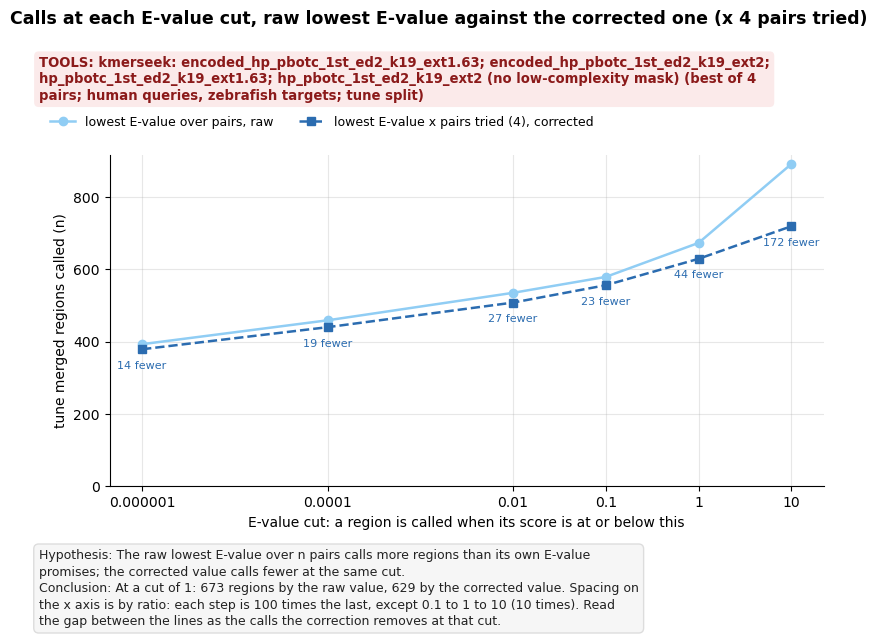

In [2]:
SHOW = ["accession", "species", "merged_region_id", "merged_start", "merged_end", "split",
        "n_arms_fired", "n_arms_tried", "evalue_min", "evalue_best_of_n_corrected",
        "mean_idf_max", "evalue_min_arms", "mean_idf_max_arms"]
named = scores.join(queries.select("accession", "hgnc_symbol"), on="accession", how="left")
print(named.filter(pl.col("hgnc_symbol").is_in(["HLA-A", "TAP1", "TNF", "C4A", "NOTCH4"]))
      .select(["hgnc_symbol"] + SHOW).sort("hgnc_symbol", "merged_start"))
print(scores.select("evalue_min", "evalue_best_of_n_corrected", "mean_idf_max", "n_arms_fired").describe())
print("pairs tied for the best E-value:", scores["evalue_min_arms"].list.len().value_counts().sort("evalue_min_arms").to_dicts())
print("pairs tied for the best mean IDF:", scores["mean_idf_max_arms"].list.len().value_counts().sort("mean_idf_max_arms").to_dicts())

CUTS = [1e-6, 1e-4, 1e-2, 0.1, 1.0, 10.0]
tune_s = scores.filter(pl.col("split") == "tune")
gap = pl.DataFrame([
    {"cut": c,
     "n_called_raw": int((tune_s["evalue_min"] <= c).sum()),
     "n_called_corrected": int((tune_s["evalue_best_of_n_corrected"] <= c).sum()),
     "precision_pfam_raw": tune_s.filter(pl.col("evalue_min") <= c)["merged_pfam_is_true"].mean(),
     "precision_pfam_corrected": tune_s.filter(pl.col("evalue_best_of_n_corrected") <= c)["merged_pfam_is_true"].mean()}
    for c in CUTS])
print("\ntune regions called at each E-value cut, raw and corrected:")
print(gap)

RAW_C, COR_C = "#90CDF4", "#2B6CB0"
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(gap["cut"], gap["n_called_raw"], color=RAW_C, marker="o", lw=1.8, label="lowest E-value over pairs, raw")
ax.plot(gap["cut"], gap["n_called_corrected"], color=COR_C, marker="s", lw=1.8, ls="--",
        label="lowest E-value x pairs tried (4), corrected")
for c, a, b in gap.select("cut", "n_called_raw", "n_called_corrected").iter_rows():
    ax.annotate(f"{a - b:_} fewer", (c, b), xytext=(0, -14), textcoords="offset points",
                ha="center", fontsize=8, color=COR_C)
ax.set_xscale("log")
ax.set_xticks(CUTS, ["0.000001", "0.0001", "0.01", "0.1", "1", "10"])
ax.minorticks_off()
ax.set_xlabel("E-value cut: a region is called when its score is at or below this")
ax.set_ylabel("tune merged regions called (n)")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
h, l = ax.get_legend_handles_labels()
fig.legend(h, l, loc="upper left", bbox_to_anchor=(0.0, 1.0), ncol=2, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.92))
g1 = gap.filter(pl.col("cut") == 1.0).row(0, named=True)
mu.finish_figure(
    fig, FIG / "262_best_of_n_raw_vs_corrected_calls_by_cut_zebrafish_tune.png",
    tools=mu.tools_text(kmerseek=ARMS, lc=False,
                        note="best of 4 pairs; human queries, zebrafish targets; tune split"),
    title="Calls at each E-value cut, raw lowest E-value against the corrected one (x 4 pairs tried)",
    hypothesis="The raw lowest E-value over n pairs calls more regions than its own E-value "
               "promises; the corrected value calls fewer at the same cut.",
    conclusion=(f"At a cut of 1: {g1['n_called_raw']:_} regions by the raw value, "
                f"{g1['n_called_corrected']:_} by the corrected value. Spacing on the x axis is "
                "by ratio: each step is 100 times the last, except 0.1 to 1 to 10 (10 times). "
                "Read the gap between the lines as the calls the correction removes at that cut."),
    layout=False,
)

## Precision and recall on tune, for each score

Each line is one ranking, read from the strictest threshold (left, few calls) to the
loosest (right, every region the table holds). Rows are truth sets, columns are the three
scores. In every panel:
- best of n: every merged region, scored by the best any pair gave it;
- the single pair with the highest tune average precision for that score and truth set,
  scored by its own value, on the regions it called;
- the Kyte-Doolittle scan, the same in all three columns of a row since it has its own
  score (its best window mean hydropathy, higher is stronger).

The dotted line is precision 0.5; the ringed point is the loosest threshold at or above it.
Average precision (AP) = the sum over thresholds of precision x the recall gained there.

In [3]:
nf_tune = rb.n_features(truth, "tune", len(SPECIES))
nf_test = rb.n_features(truth, "test", len(SPECIES))
print(f"truth features x {len(SPECIES)} species: tune {nf_tune}, test {nf_test}")

def best_of_n(split: str, nf: dict) -> rb.Calls:
    return rb.kmerseek_calls(scores.filter(pl.col("split") == split), truth_pairs, nf)

ONE = tried.with_columns(n_arms_tried=pl.lit(1, pl.UInt32))
single_scores = {a: rb.attach_truth(rb.region_scores(calls.filter(pl.col("arm") == a), ONE), table)
                 for a in ARMS}

def single(arm: str, split: str, nf: dict) -> rb.Calls:
    return rb.kmerseek_calls(single_scores[arm].filter(pl.col("split") == split), truth_pairs, nf)

seqs = rb.load_query_seqs(queries["accession"].to_list())
print(f"query sequences read: {len(seqs)} of {queries.height}")
kd = {s: rb.kd_calls(seqs, truth, SPECIES, s, nf) for s, nf in (("tune", nf_tune), ("test", nf_test))}
print("Kyte-Doolittle segments per split:", {s: c.regions.height for s, c in kd.items()})

bon_tune = best_of_n("tune", nf_tune)
rows, curves = [], {}
for sc, low in rb.SCORES.items():
    for ts in rb.TRUTH_SETS:
        cur = rb.pr_curve(bon_tune, sc, low, ts)
        curves[("best of n", sc, ts)] = cur
        rows.append(dict(method="best of n", score=sc, truth_set=ts, ap=rb.average_precision(cur)))
        for a in ARMS:
            # A single pair's corrected value equals its raw value (n = 1).
            cur_a = rb.pr_curve(single(a, "tune", nf_tune), sc, low, ts)
            curves[(a, sc, ts)] = cur_a
            rows.append(dict(method=a, score=sc, truth_set=ts, ap=rb.average_precision(cur_a)))
for ts in rb.TRUTH_SETS:
    cur = rb.pr_curve(kd["tune"], "kd_score", False, ts)
    curves[("Kyte-Doolittle", "kd_score", ts)] = cur
    rows.append(dict(method="Kyte-Doolittle scan", score="kd_score", truth_set=ts, ap=rb.average_precision(cur)))
ap = pl.DataFrame(rows)
print(ap.with_columns(pl.col("ap").round(4)).pivot(on="truth_set", index=["score", "method"], values="ap"))

best_arm = {}
for sc in rb.SCORES:
    for ts in rb.TRUTH_SETS:
        s = ap.filter((pl.col("score") == sc) & (pl.col("truth_set") == ts) & pl.col("method").is_in(ARMS))
        best_arm[(sc, ts)] = s.sort(["ap", "method"], descending=[True, False])["method"][0]
print("\nsingle pair with the highest tune AP, per score and truth set:")
for k, v in best_arm.items():
    print(f"  {k[0]:28s} {k[1]:10s} {v}")

thresholds = []
for sc, low in list(rb.SCORES.items()) + [("kd_score", False)]:
    for ts in rb.TRUTH_SETS:
        for method in (["best of n", best_arm[(sc, ts)]] if sc != "kd_score" else ["Kyte-Doolittle"]):
            cur = curves[(method, sc, ts)]
            t = rb.loosest_threshold(cur)
            thresholds.append(dict(method=method, score=sc, truth_set=ts,
                                   max_precision=float(np.nanmax(cur["precision"].to_numpy())),
                                   **({k: t[k] for k in ("threshold", "n_called", "precision", "recall")}
                                      if t else {"threshold": None, "n_called": None, "precision": None, "recall": None})))
thr = pl.DataFrame(thresholds, infer_schema_length=None)
print("\nloosest threshold with tune precision >= 0.5 (null: no threshold reaches 0.5):")
print(thr)

truth features x 1 species: tune {'swissprot': 3505, 'pfam': 1250}, test {'swissprot': 3677, 'pfam': 1185}
query sequences read: 998 of 998
Kyte-Doolittle segments per split: {'tune': 794, 'test': 789}


shape: (16, 4)
┌────────────────────────────┬──────────────────────────────────────┬───────────┬────────┐
│ score                      ┆ method                               ┆ swissprot ┆ pfam   │
│ ---                        ┆ ---                                  ┆ ---       ┆ ---    │
│ str                        ┆ str                                  ┆ f64       ┆ f64    │
╞════════════════════════════╪══════════════════════════════════════╪═══════════╪════════╡
│ evalue_min                 ┆ best of n                            ┆ 0.0334    ┆ 0.1717 │
│ evalue_min                 ┆ encoded_hp_pbotc_1st_ed2_k19_ext1.63 ┆ 0.0301    ┆ 0.1614 │
│ evalue_min                 ┆ encoded_hp_pbotc_1st_ed2_k19_ext2    ┆ 0.0305    ┆ 0.1647 │
│ evalue_min                 ┆ hp_pbotc_1st_ed2_k19_ext1.63         ┆ 0.0256    ┆ 0.1468 │
│ evalue_min                 ┆ hp_pbotc_1st_ed2_k19_ext2            ┆ 0.0271    ┆ 0.1523 │
│ evalue_best_of_n_corrected ┆ best of n                            ┆ 0.033

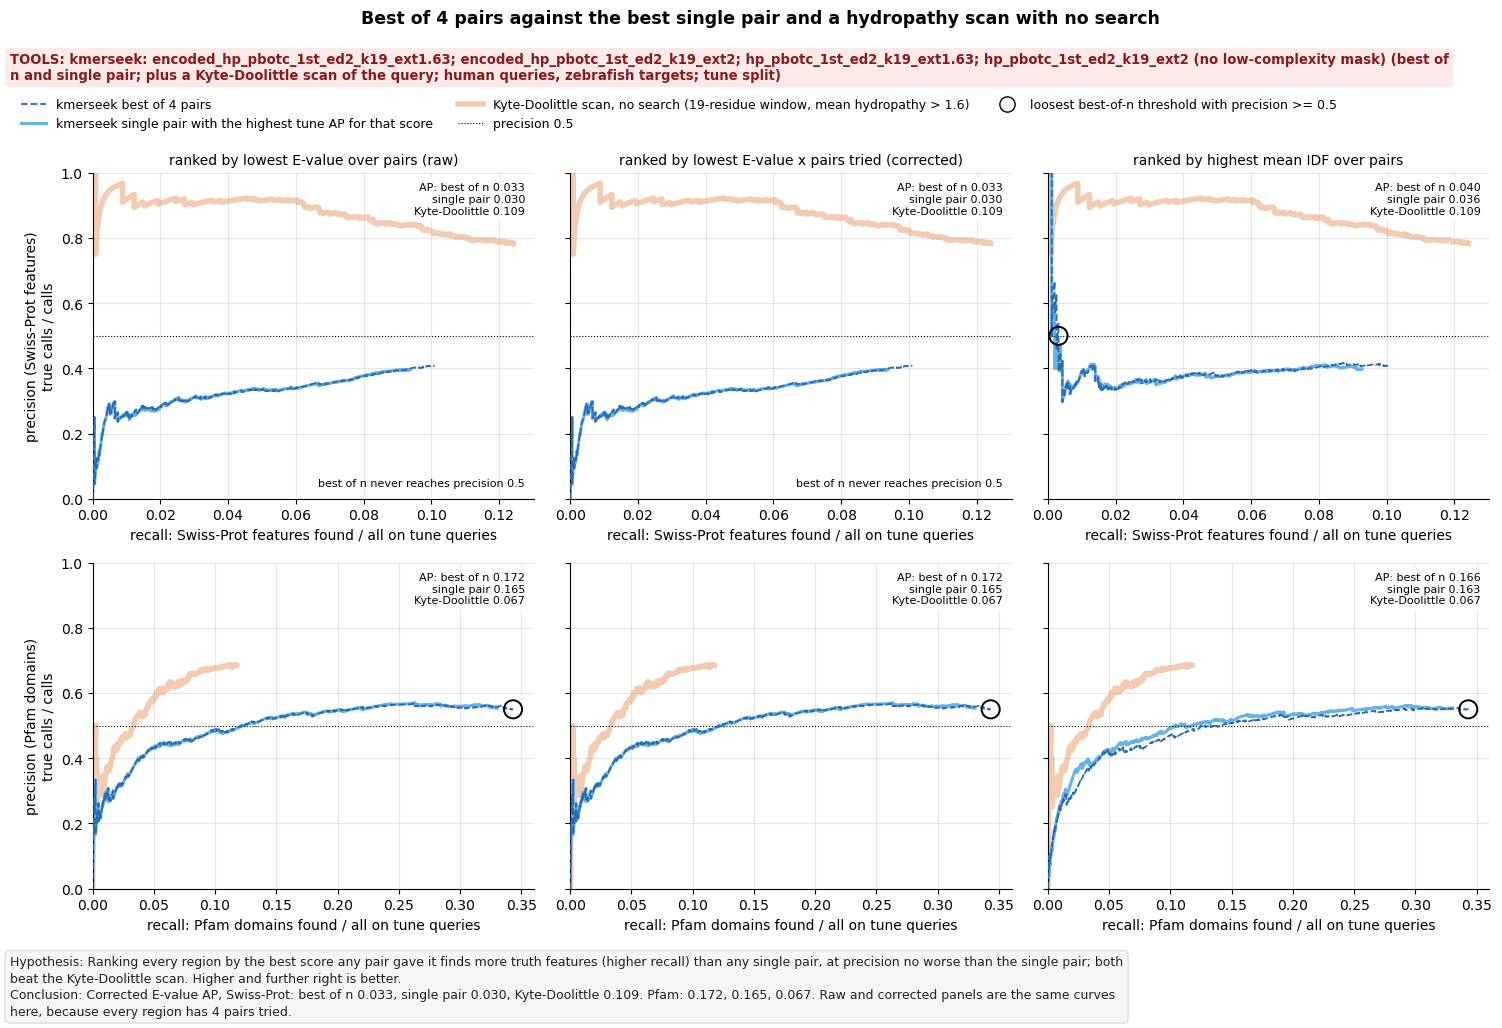

In [4]:
BON_C, ARM_C, KD_C = "#2B6CB0", "#63B3ED", "#DD6B20"
TS_NAME = {"swissprot": "Swiss-Prot features", "pfam": "Pfam domains"}
fig, axes = plt.subplots(2, 3, figsize=(15, 8.6), sharey="row")
for i, ts in enumerate(rb.TRUTH_SETS):
    k = curves[("Kyte-Doolittle", "kd_score", ts)]
    for j, sc in enumerate(rb.SCORES):
        ax = axes[i, j]
        ax.plot(k["recall"], k["precision"], color=KD_C, lw=4, alpha=0.35, zorder=1)
        a = curves[(best_arm[(sc, ts)], sc, ts)]
        ax.plot(a["recall"], a["precision"], color=ARM_C, lw=2.2, zorder=2)
        b = curves[("best of n", sc, ts)]
        ax.plot(b["recall"], b["precision"], color=BON_C, lw=1.3, ls="--", zorder=3)
        ax.axhline(rb.TARGET_PRECISION, color="black", lw=0.8, ls=":")
        t = rb.loosest_threshold(b)
        if t:
            ax.scatter([t["recall"]], [t["precision"]], s=170, facecolors="none", edgecolors="black", lw=1.4, zorder=4)
        else:
            ax.text(0.98, 0.04, "best of n never reaches precision 0.5", transform=ax.transAxes,
                    ha="right", fontsize=8)
        apb = ap.filter((pl.col("method") == "best of n") & (pl.col("score") == sc) & (pl.col("truth_set") == ts))["ap"][0]
        apa = ap.filter((pl.col("method") == best_arm[(sc, ts)]) & (pl.col("score") == sc) & (pl.col("truth_set") == ts))["ap"][0]
        apk = ap.filter((pl.col("method") == "Kyte-Doolittle scan") & (pl.col("truth_set") == ts))["ap"][0]
        ax.text(0.98, 0.97, f"AP: best of n {apb:.3f}\nsingle pair {apa:.3f}\nKyte-Doolittle {apk:.3f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=8,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
        ax.set_ylim(0, 1)
        ax.set_xlim(left=0)
        ax.grid(alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
        if i == 0:
            ax.set_title(f"ranked by {rb.SCORE_LABELS[sc]}", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"precision ({TS_NAME[ts]})\ntrue calls / calls")
        ax.set_xlabel(f"recall: {TS_NAME[ts]} found / all on tune queries")
handles = [Line2D([], [], color=BON_C, lw=1.3, ls="--"),
           Line2D([], [], color=ARM_C, lw=2.2),
           Line2D([], [], color=KD_C, lw=4, alpha=0.35),
           Line2D([], [], color="black", lw=0.8, ls=":"),
           Line2D([], [], ls="none", marker="o", ms=11, mfc="none", mec="black")]
labels = ["kmerseek best of 4 pairs", "kmerseek single pair with the highest tune AP for that score",
          "Kyte-Doolittle scan, no search (19-residue window, mean hydropathy > 1.6)",
          "precision 0.5", "loosest best-of-n threshold with precision >= 0.5"]
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.0, 1.0), ncol=3, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.94))
apx = {(r["method"], r["score"], r["truth_set"]): r["ap"] for r in ap.to_dicts()}
mu.finish_figure(
    fig, FIG / "262_best_of_n_precision_recall_swissprot_pfam_kyte_doolittle_zebrafish_tune.png",
    tools=mu.tools_text(kmerseek=ARMS, lc=False,
                        note="best of n and single pair; plus a Kyte-Doolittle scan of the query; human queries, zebrafish targets; tune split"),
    title="Best of 4 pairs against the best single pair and a hydropathy scan with no search",
    hypothesis="Ranking every region by the best score any pair gave it finds more truth "
               "features (higher recall) than any single pair, at precision no worse than "
               "the single pair; both beat the Kyte-Doolittle scan. Higher and further right is better.",
    conclusion=(f"Corrected E-value AP, Swiss-Prot: best of n {apx[('best of n', 'evalue_best_of_n_corrected', 'swissprot')]:.3f}, "
                f"single pair {apx[(best_arm[('evalue_best_of_n_corrected', 'swissprot')], 'evalue_best_of_n_corrected', 'swissprot')]:.3f}, "
                f"Kyte-Doolittle {apx[('Kyte-Doolittle scan', 'kd_score', 'swissprot')]:.3f}. Pfam: "
                f"{apx[('best of n', 'evalue_best_of_n_corrected', 'pfam')]:.3f}, "
                f"{apx[(best_arm[('evalue_best_of_n_corrected', 'pfam')], 'evalue_best_of_n_corrected', 'pfam')]:.3f}, "
                f"{apx[('Kyte-Doolittle scan', 'kd_score', 'pfam')]:.3f}. Raw and corrected panels "
                "are the same curves here, because every region has 4 pairs tried."),
    layout=False,
)

## The frozen threshold

The rule from the top cell: the corrected E-value threshold on Swiss-Prot, or on Pfam when
no Swiss-Prot threshold reaches precision 0.5. The single pair's threshold is chosen the
same way on its own curve, for the test comparison.

In [5]:
def pick(method: str, sc: str, ts: str):
    r = thr.filter((pl.col("method") == method) & (pl.col("score") == sc) & (pl.col("truth_set") == ts))
    return r.row(0, named=True) if r.height and r["threshold"][0] is not None else None

FREEZE_TS = "swissprot" if pick("best of n", rb.RANK_SCORE, "swissprot") else "pfam"
frozen = pick("best of n", rb.RANK_SCORE, FREEZE_TS)
THR = frozen["threshold"]
SINGLE = best_arm[(rb.RANK_SCORE, FREEZE_TS)]
single_frozen = pick(SINGLE, rb.RANK_SCORE, FREEZE_TS)
THR_SINGLE = single_frozen["threshold"] if single_frozen else None
kd_frozen = pick("Kyte-Doolittle", "kd_score", FREEZE_TS)
THR_KD = kd_frozen["threshold"] if kd_frozen else None
print(f"frozen on: {FREEZE_TS}")
print(f"best of n: corrected E-value <= {THR:.4g} (raw <= {THR / 4:.4g} for 4 pairs tried); "
      f"tune calls {frozen['n_called']:_}, precision {frozen['precision']:.3f}, recall {frozen['recall']:.3f}")
print(f"best of n, highest tune precision anywhere on the Swiss-Prot curve: "
      f"{thr.filter((pl.col('method') == 'best of n') & (pl.col('score') == rb.RANK_SCORE) & (pl.col('truth_set') == 'swissprot'))['max_precision'][0]:.3f}")
print(f"tune regions in the table: {bon_tune.regions.height:_}; the frozen threshold keeps "
      f"{frozen['n_called']:_} of them")
print(f"single pair {SINGLE}: E-value <= {THR_SINGLE}" + (f", tune calls {single_frozen['n_called']:_}" if single_frozen else ""))
print(f"Kyte-Doolittle: best window mean >= {THR_KD}" + (f", tune calls {kd_frozen['n_called']:_}" if kd_frozen else ""))

frozen on: pfam
best of n: corrected E-value <= 39.9 (raw <= 9.974 for 4 pairs tried); tune calls 891, precision 0.550, recall 0.343
best of n, highest tune precision anywhere on the Swiss-Prot curve: 0.409
tune regions in the table: 891; the frozen threshold keeps 891 of them
single pair encoded_hp_pbotc_1st_ed2_k19_ext2: E-value <= 9.973765847017171, tune calls 847
Kyte-Doolittle: best window mean >= 1.6000000000000003, tune calls 794


## Shuffled queries: false calls per query at the frozen threshold

Every region on a shuffled query is false. The count of those passing the frozen threshold,
divided by the shuffled queries searched (times target species), is the false-call rate
per query. The figure draws calls per query against the corrected E-value threshold for
real tune queries, with the shuffled-query line beside it once that run exists.

frozen threshold: corrected E-value <= 39.9
shape: (2, 6)
┌───────┬───────────────────┬────────────┬──────────────────────┬────────────────┬──────────────────────────┐
│ split ┆ queries_x_species ┆ real_calls ┆ real_calls_per_query ┆ shuffled_calls ┆ shuffled_calls_per_query │
│ ---   ┆ ---               ┆ ---        ┆ ---                  ┆ ---            ┆ ---                      │
│ str   ┆ i64               ┆ i64        ┆ f64                  ┆ null           ┆ null                     │
╞═══════╪═══════════════════╪════════════╪══════════════════════╪════════════════╪══════════════════════════╡
│ tune  ┆ 511               ┆ 891        ┆ 1.74364              ┆ null           ┆ null                     │
│ test  ┆ 487               ┆ 822        ┆ 1.687885             ┆ null           ┆ null                     │
└───────┴───────────────────┴────────────┴──────────────────────┴────────────────┴──────────────────────────┘


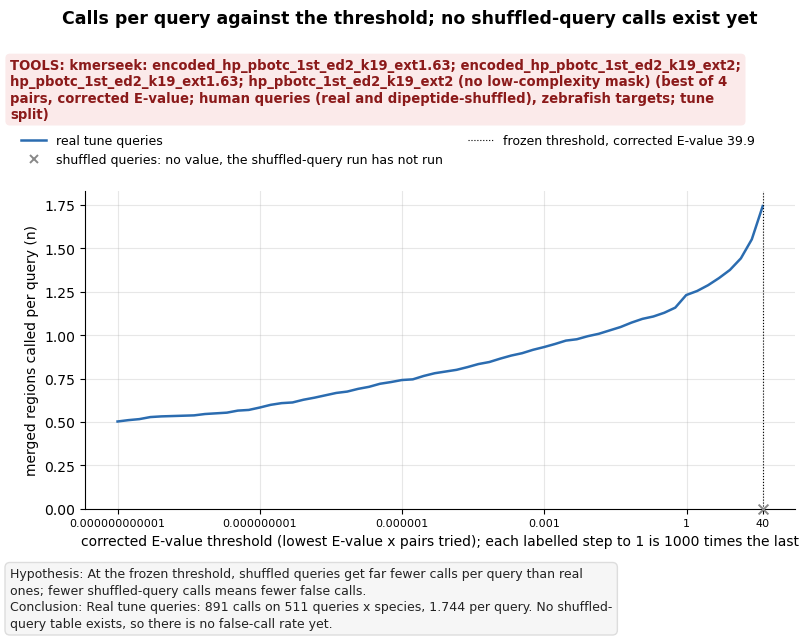

In [6]:
if DECOY_REDUCED.exists():
    d_calls = rb.merged_calls(DECOY_REDUCED)
    d_tried = rb.arms_tried(pl.read_parquet(DECOY_REDUCED / "reduce_summary.parquet"))
    decoy = rb.region_scores(d_calls, d_tried).with_columns(split=rt.query_split(pl.col("accession")))
else:
    decoy = None
n_q = {s: queries.filter(pl.col("split") == s).height for s in ("tune", "test")}
n_searched = {s: n_q[s] * len(SPECIES) for s in n_q}
dec_rows = []
for s in ("tune", "test"):
    real = scores.filter((pl.col("split") == s) & (pl.col(rb.RANK_SCORE) <= THR)).height
    fake = (decoy.filter((pl.col("split") == s) & (pl.col(rb.RANK_SCORE) <= THR)).height
            if decoy is not None else None)
    dec_rows.append(dict(split=s, queries_x_species=n_searched[s], real_calls=real,
                         real_calls_per_query=real / n_searched[s],
                         shuffled_calls=fake,
                         shuffled_calls_per_query=(fake / n_searched[s]) if fake is not None else None))
dec = pl.DataFrame(dec_rows, infer_schema_length=None)
print(f"frozen threshold: corrected E-value <= {THR:.4g}")
print(dec)

grid_t = np.logspace(-12, np.log10(THR), 60)
ts_ = scores.filter(pl.col("split") == "tune")[rb.RANK_SCORE].to_numpy()
real_curve = [(ts_ <= t).sum() / n_searched["tune"] for t in grid_t]
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(grid_t, real_curve, color=BON_C, lw=1.8)
handles = [Line2D([], [], color=BON_C, lw=1.8)]
labels = ["real tune queries"]
if decoy is not None:
    dt = decoy.filter(pl.col("split") == "tune")[rb.RANK_SCORE].to_numpy()
    ax.plot(grid_t, [(dt <= t).sum() / n_searched["tune"] for t in grid_t], color="#C53030", lw=1.8, ls="--")
    handles.append(Line2D([], [], color="#C53030", lw=1.8, ls="--"))
    labels.append("shuffled tune queries (every call false)")
else:
    ax.scatter([THR], [0], marker="x", color="#888888", s=50, lw=1.4, clip_on=False, zorder=3)
    handles.append(Line2D([], [], ls="none", marker="x", color="#888888", mew=1.4))
    labels.append("shuffled queries: no value, the shuffled-query run has not run")
ax.axvline(THR, color="black", lw=0.8, ls=":")
handles.append(Line2D([], [], color="black", lw=0.8, ls=":"))
labels.append(f"frozen threshold, corrected E-value {THR:.3g}")
ax.set_xscale("log")
ticks = [1e-12, 1e-9, 1e-6, 1e-3, 1, THR]
ax.set_xticks(ticks, ["0.000000000001", "0.000000001", "0.000001", "0.001", "1", f"{THR:.0f}"], fontsize=8)
ax.minorticks_off()
ax.set_xlabel("corrected E-value threshold (lowest E-value x pairs tried); each labelled step to 1 is 1000 times the last")
ax.set_ylabel("merged regions called per query (n)")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.0, 1.0), ncol=2, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.88))
d_t = dec.row(0, named=True)
mu.finish_figure(
    fig, FIG / "262_best_of_n_calls_per_query_real_vs_shuffled_zebrafish_tune.png",
    tools=mu.tools_text(kmerseek=ARMS, lc=False,
                        note="best of 4 pairs, corrected E-value; human queries (real and dipeptide-shuffled), zebrafish targets; tune split"),
    title=("Calls per query against the threshold; no shuffled-query calls exist yet" if decoy is None
           else "Calls per query against the threshold, real and shuffled queries"),
    hypothesis="At the frozen threshold, shuffled queries get far fewer calls per query than "
               "real ones; fewer shuffled-query calls means fewer false calls.",
    conclusion=(f"Real tune queries: {d_t['real_calls']:_} calls on {d_t['queries_x_species']:_} queries x species, "
                f"{d_t['real_calls_per_query']:.3f} per query. "
                + ("No shuffled-query table exists, so there is no false-call rate yet."
                   if decoy is None else
                   f"Shuffled: {d_t['shuffled_calls']:_}, {d_t['shuffled_calls_per_query']:.3f} per query.")),
    layout=False,
)

## The frozen threshold on test

Best of n at the frozen corrected E-value, beside the single pair at its own tune threshold,
the Kyte-Doolittle scan at its own, and combiner A's frozen panel from
`261_intersection_panel.yaml`. Nothing here was chosen on test.

In [7]:
panel_a = yaml.safe_load(PANEL_A_YAML.read_text())
assert panel_a["input_table_sha256"] == sha256(TABLE), "notebook 261 read a different table"
PANEL_A, EMAX_A = panel_a["panel"], panel_a["emax"]
bon_test = best_of_n("test", nf_test)
test_rows = []
for split, bon, nf in (("tune", bon_tune, nf_tune), ("test", bon_test, nf_test)):
    test_rows.append(dict(split=split, method="best of 4 pairs, corrected E-value",
                          **rb.at_threshold(bon, rb.RANK_SCORE, True, THR)))
    if THR_SINGLE is not None:
        test_rows.append(dict(split=split, method=f"single pair {SINGLE}",
                              **rb.at_threshold(single(SINGLE, split, nf), "evalue_min", True, THR_SINGLE)))
    if THR_KD is not None:
        test_rows.append(dict(split=split, method="Kyte-Doolittle scan",
                              **rb.at_threshold(kd[split], "kd_score", False, THR_KD)))
    a = rc.Scorer(table, truth_pairs, truth, split).score(PANEL_A, EMAX_A)
    test_rows.append(dict(split=split, method=f"combiner A, {len(PANEL_A)} pairs, E < {EMAX_A:g}",
                          threshold=EMAX_A, **{k: a[k] for k in a if k.startswith(("n_called", "precision_", "n_found_", "recall_"))}))
report = pl.DataFrame(test_rows, infer_schema_length=None).select(
    "split", "method", "threshold", "n_called",
    "precision_swissprot", "recall_swissprot", "precision_pfam", "recall_pfam",
    "n_called_on_swissprot_queries", "n_found_swissprot", "n_called_on_pfam_queries", "n_found_pfam")
print(report)

shape: (8, 12)
┌───────┬────────────────────────────────────┬───────────┬──────────┬─────────────────────┬──────────────────┬────────────────┬─────────────┬───────────────────────────────┬───────────────────┬──────────────────────────┬──────────────┐
│ split ┆ method                             ┆ threshold ┆ n_called ┆ precision_swissprot ┆ recall_swissprot ┆ precision_pfam ┆ recall_pfam ┆ n_called_on_swissprot_queries ┆ n_found_swissprot ┆ n_called_on_pfam_queries ┆ n_found_pfam │
│ ---   ┆ ---                                ┆ ---       ┆ ---      ┆ ---                 ┆ ---              ┆ ---            ┆ ---         ┆ ---                           ┆ ---               ┆ ---                      ┆ ---          │
│ str   ┆ str                                ┆ f64       ┆ i64      ┆ f64                 ┆ f64              ┆ f64            ┆ f64         ┆ i64                           ┆ i64               ┆ i64                      ┆ i64          │
╞═══════╪════════════════════════════════

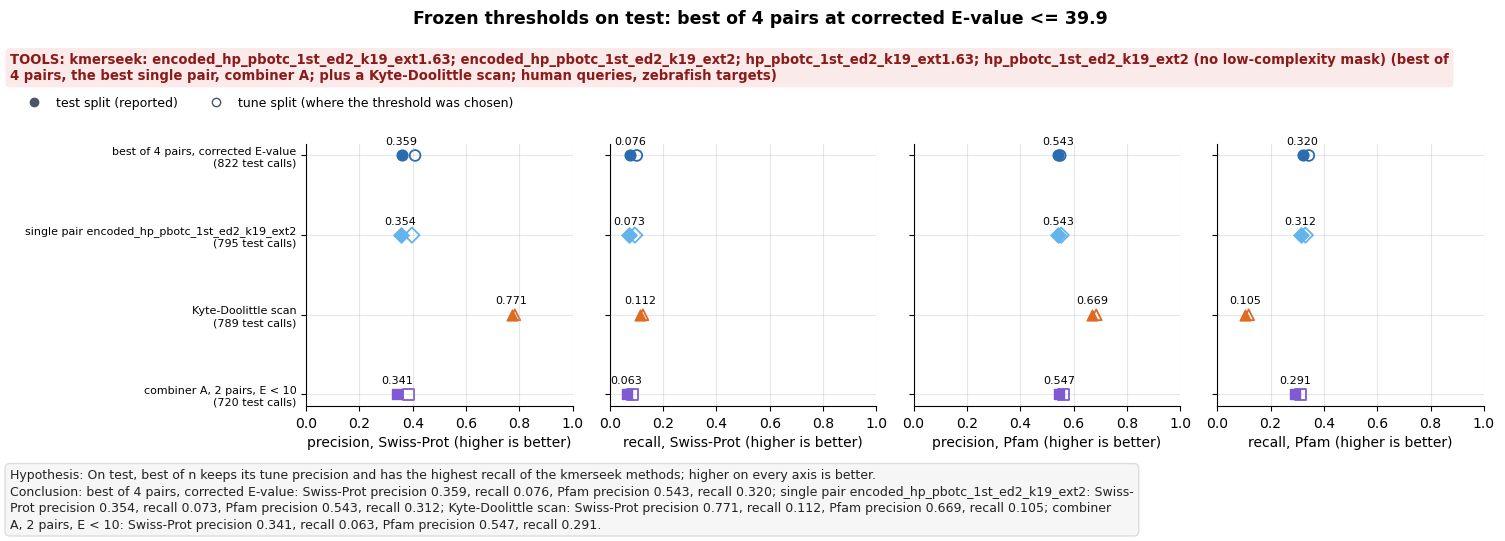

In [8]:
rep_test = report.filter(pl.col("split") == "test")
METHODS = rep_test["method"].to_list()
M_COLOR = {m: (BON_C if m.startswith("best of") else ARM_C if m.startswith("single") else
               KD_C if m.startswith("Kyte") else "#805AD5") for m in METHODS}
M_MARK = {m: ("o" if m.startswith("best of") else "D" if m.startswith("single") else
              "^" if m.startswith("Kyte") else "s") for m in METHODS}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
cols = [("precision_swissprot", "precision, Swiss-Prot"), ("recall_swissprot", "recall, Swiss-Prot"),
        ("precision_pfam", "precision, Pfam"), ("recall_pfam", "recall, Pfam")]
y = np.arange(len(METHODS))
for ax, (c, name) in zip(axes, cols):
    for yi, m in zip(y, METHODS):
        v_test = rep_test.filter(pl.col("method") == m)[c][0]
        v_tune = report.filter((pl.col("split") == "tune") & (pl.col("method") == m))[c][0]
        ax.scatter([v_tune], [yi], marker=M_MARK[m], s=60, facecolors="none", edgecolors=M_COLOR[m], lw=1.3)
        ax.scatter([v_test], [yi], marker=M_MARK[m], s=60, color=M_COLOR[m])
        ax.annotate(f"{v_test:.3f}", (v_test, yi), xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=8)
    ax.set_xlabel(name + " (higher is better)")
    ax.set_xlim(0, 1)
    ax.grid(axis="x", alpha=0.3)
    ax.set_yticks(y, [f"{m}\n({rep_test.filter(pl.col('method') == m)['n_called'][0]:_} test calls)" for m in METHODS], fontsize=8)
    for yi in y:
        ax.axhline(yi, color="#E2E8F0", lw=0.8, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].invert_yaxis()
handles = [Line2D([], [], ls="none", marker="o", color="#4A5568"),
           Line2D([], [], ls="none", marker="o", mfc="none", mec="#4A5568")]
fig.legend(handles, ["test split (reported)", "tune split (where the threshold was chosen)"],
           loc="upper left", bbox_to_anchor=(0.0, 1.0), ncol=2, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.9))
b = rep_test.row(0, named=True)
mu.finish_figure(
    fig, FIG / "262_best_of_n_frozen_threshold_test_vs_single_pair_combiner_a_kyte_doolittle_zebrafish.png",
    tools=mu.tools_text(kmerseek=ARMS, lc=False,
                        note="best of 4 pairs, the best single pair, combiner A; plus a Kyte-Doolittle scan; human queries, zebrafish targets"),
    title=f"Frozen thresholds on test: best of 4 pairs at corrected E-value <= {THR:.3g}",
    hypothesis="On test, best of n keeps its tune precision and has the highest recall of the "
               "kmerseek methods; higher on every axis is better.",
    conclusion=("; ".join(f"{r['method']}: Swiss-Prot precision {r['precision_swissprot']:.3f}, recall "
                          f"{r['recall_swissprot']:.3f}, Pfam precision {r['precision_pfam']:.3f}, recall {r['recall_pfam']:.3f}"
                          for r in rep_test.to_dicts()) + "."),
    layout=False,
)

## Saving the frozen threshold

`262_best_of_n_threshold.yaml` holds the threshold, the rule that chose it, every score's
tune threshold in both truth sets, the tune and test numbers, the shuffled-query rate
(null until that run exists) and the input table's checksum.

In [9]:
def clean(d: dict) -> dict:
    return {k: (None if isinstance(v, float) and v != v else
                float(v) if isinstance(v, (np.floating,)) else int(v) if isinstance(v, np.integer) else v)
            for k, v in d.items()}

record = {
    "combiner": "B, best of n: every merged region any pair called, ranked by the best score any pair gave it",
    "rank_score": rb.RANK_SCORE,
    "rank_score_definition": "n_arms_tried * min over pairs of region_evalue; n_arms_tried = pairs whose "
                             "search was run on that query and target species",
    "threshold": float(THR),
    "threshold_raw_equivalent_for_4_pairs": float(THR / 4),
    "frozen_on_truth_set": FREEZE_TS,
    "selection": "tune split; loosest threshold with precision >= 0.5 (landed >= 0.5); corrected "
                 "E-value on Swiss-Prot, or Pfam when no Swiss-Prot threshold reaches 0.5",
    "pairs": ARMS,
    "n_arms_tried": {r["species"]: int(r["n_arms_tried"]) for r in tried.to_dicts()},
    "tune_thresholds_all_scores": [clean(r) for r in thr.to_dicts()],
    "single_pair": SINGLE,
    "single_pair_threshold": THR_SINGLE,
    "tune": clean({k: v for k, v in report.row(0, named=True).items() if k not in ("split", "method")}),
    "test": clean({k: v for k, v in rep_test.row(0, named=True).items() if k not in ("split", "method")}),
    "shuffled_queries": [clean(r) for r in dec.to_dicts()],
    "input_table": str(TABLE),
    "input_table_sha256": sha256(TABLE),
    "input_note": f"{len(ARMS)} pairs, species {SPECIES}; shuffled-query files "
                  f"{'present' if decoy is not None else 'absent'}",
    "notebook": "notebooks/262_combiner_b_best_of_n.ipynb",
    "written": date.today().isoformat(),
}
OUT_YAML.write_text(yaml.safe_dump(record, sort_keys=False, width=100))
print(OUT_YAML.read_text())

combiner: 'B, best of n: every merged region any pair called, ranked by the best score any pair gave it'
rank_score: evalue_best_of_n_corrected
rank_score_definition: n_arms_tried * min over pairs of region_evalue; n_arms_tried = pairs whose search
  was run on that query and target species
threshold: 39.895063388068685
threshold_raw_equivalent_for_4_pairs: 9.973765847017171
frozen_on_truth_set: pfam
selection: tune split; loosest threshold with precision >= 0.5 (landed >= 0.5); corrected E-value on Swiss-Prot,
  or Pfam when no Swiss-Prot threshold reaches 0.5
pairs:
- encoded_hp_pbotc_1st_ed2_k19_ext1.63
- encoded_hp_pbotc_1st_ed2_k19_ext2
- hp_pbotc_1st_ed2_k19_ext1.63
- hp_pbotc_1st_ed2_k19_ext2
n_arms_tried:
  zebrafish: 4
  fly: 1
tune_thresholds_all_scores:
- method: best of n
  score: evalue_min
  truth_set: swissprot
  max_precision: 0.408716136631331
  threshold: null
  n_called: null
  precision: null
  recall: null
- method: encoded_hp_pbotc_1st_ed2_k19_ext2
  score: evalue

## Multi-domain queries: how many domains each method lands

The same question and figure as [notebook 261](261_combiner_a_intersection_panel.ipynb):
for test queries with at least two Pfam domains, how many of those domains each method
lands in, per query and target species. A domain is landed when at least half of one call
lies inside it.

- Best of 4 pairs: merged regions at the frozen corrected E-value.
- Combiner A: notebook 261's frozen panel.
- Single pair: merged regions that pair calls, at its own tune threshold.
- phmmer: each per-domain hit's query span at i-Evalue < 10, the same cut notebook 260
  put on kmerseek's E-value.

The kmerseek rows use merged-region extents, which grow when calls chain across domain
borders; phmmer's hits are not merged. A merged region that spans two domains lands in
neither. Best of n uses every merged region, so it can only land as many or more domains
than combiner A or one pair at the thresholds frozen here (its regions include theirs); the
question is how far it gets toward phmmer.

In [10]:
pf_dom = (truth.filter(pl.col("truth_set") == "pfam").unique(subset=rc.FEATURE_KEY)
          .with_columns(split=rt.query_split(pl.col("accession"))))
multi = (pf_dom.filter(pl.col("split") == "test").group_by("accession").agg(n_domains=pl.len())
         .filter(pl.col("n_domains") >= 2))
grid = multi.join(pl.DataFrame({"species": SPECIES}), how="cross")
print(f"test queries with >= 2 Pfam domains: {multi.height}; domains on them: {multi['n_domains'].sum():_}")

def spans_from(c: rb.Calls, score: str, low: bool, t: float) -> pl.DataFrame:
    r = c.regions.filter(pl.col(score) <= t if low else pl.col(score) >= t)
    return r.select("accession", "species", start="merged_start", end="merged_end")

scorer_a = rc.Scorer(table, truth_pairs, truth, "test")
a_rid = scorer_a.called(PANEL_A, EMAX_A)
a_spans = (scorer_a.regions.filter(pl.col("rid").is_in(a_rid))
           .join(scorer_a.t.unique(subset=rc.KEY).select(rc.KEY + ["merged_start", "merged_end"]), on=rc.KEY)
           .select("accession", "species", start="merged_start", end="merged_end"))
phm = pl.concat([rc.load_phmmer(PHMMER_DIR / f"human_vs_{sp}.hmmer3_phmmer.tsv.gz", sp) for sp in SPECIES])
phm = phm.filter(pl.col("evalue") < rt.EVALUE_MAX).select("accession", "species", start="qstart", end="qend")
spans = {"best of 4 pairs": spans_from(bon_test, rb.RANK_SCORE, True, THR),
         f"combiner A, {len(PANEL_A)} pairs": a_spans}
if THR_SINGLE is not None:
    spans["single pair"] = spans_from(single(SINGLE, "test", nf_test), "evalue_min", True, THR_SINGLE)
spans["phmmer"] = phm
dom_in = pf_dom.filter(pl.col("accession").is_in(multi["accession"].implode()))
counts = grid
for name, s in spans.items():
    c = rc.domains_landed(s.filter(pl.col("accession").is_in(multi["accession"].implode())), dom_in, "start", "end")
    counts = counts.join(c.rename({"n_landed": name}), on=["accession", "species"], how="left")
MD = list(spans)
counts = counts.with_columns(pl.col(n).fill_null(0) for n in MD)
dist = (counts.unpivot(index=["accession", "species", "n_domains"], on=MD, variable_name="method", value_name="n_landed")
        .group_by("method", "n_landed").len("n_queries").sort("method", "n_landed"))
print(dist.pivot(on="method", index="n_landed", values="n_queries").fill_null(0).sort("n_landed"))
print(counts.select(*[pl.col(n).mean().round(3).alias(f"mean | {n}") for n in MD],
                    *[(pl.col(n) == 0).sum().alias(f"zero landed | {n}") for n in MD]).unpivot())
B = MD[0]
cmp = counts.select(best_of_n_more_than_phmmer=(pl.col(B) > pl.col("phmmer")).sum(),
                    same=(pl.col(B) == pl.col("phmmer")).sum(),
                    phmmer_more=(pl.col(B) < pl.col("phmmer")).sum(),
                    best_of_n_more_than_combiner_a=(pl.col(B) > pl.col(MD[1])).sum())
print(cmp)
named_md = counts.join(queries.select("accession", "hgnc_symbol"), on="accession").sort("n_domains", descending=True)
print(named_md.head(12))

test queries with >= 2 Pfam domains: 241; domains on them: 939
shape: (14, 5)
┌──────────┬─────────────────┬─────────────────────┬────────┬─────────────┐
│ n_landed ┆ best of 4 pairs ┆ combiner A, 2 pairs ┆ phmmer ┆ single pair │
│ ---      ┆ ---             ┆ ---                 ┆ ---    ┆ ---         │
│ u32      ┆ u32             ┆ u32                 ┆ u32    ┆ u32         │
╞══════════╪═════════════════╪═════════════════════╪════════╪═════════════╡
│ 0        ┆ 98              ┆ 114                 ┆ 18     ┆ 102         │
│ 1        ┆ 105             ┆ 96                  ┆ 52     ┆ 103         │
│ 2        ┆ 33              ┆ 27                  ┆ 82     ┆ 31          │
│ 3        ┆ 4               ┆ 3                   ┆ 32     ┆ 4           │
│ 4        ┆ 0               ┆ 0                   ┆ 25     ┆ 0           │
│ 5        ┆ 0               ┆ 0                   ┆ 12     ┆ 0           │
│ 6        ┆ 1               ┆ 1                   ┆ 5      ┆ 1           │
│ 7       

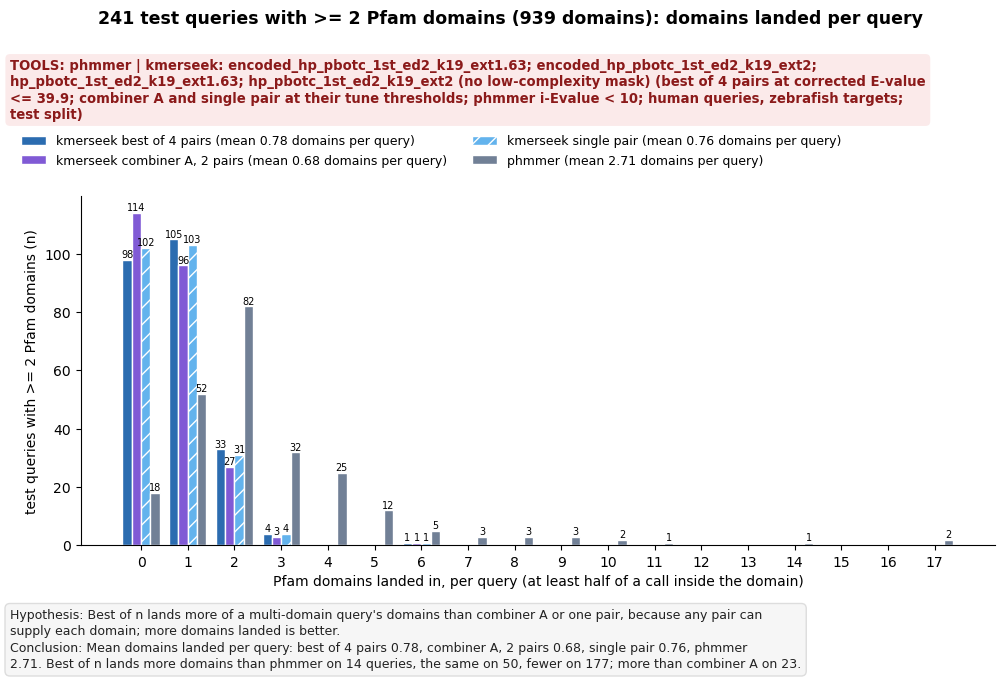

In [11]:
MD_COLOR = {MD[0]: BON_C, MD[1]: "#805AD5", "single pair": ARM_C, "phmmer": "#718096"}
MD_HATCH = {MD[0]: None, MD[1]: None, "single pair": "//", "phmmer": None}
xs = np.arange(0, int(dist["n_landed"].max()) + 1)
w = 0.8 / len(MD)
fig, ax = plt.subplots(figsize=(10, 4.8))
for i, m in enumerate(MD):
    d = dict(dist.filter(pl.col("method") == m).select("n_landed", "n_queries").iter_rows())
    ys = [d.get(int(x), 0) for x in xs]
    off = (i - (len(MD) - 1) / 2) * w
    tool = "" if m == "phmmer" else "kmerseek "
    ax.bar(xs + off, ys, width=w, color=MD_COLOR[m], hatch=MD_HATCH[m], edgecolor="white",
           label=f"{tool}{m} (mean {counts[m].mean():.2f} domains per query)")
    for x, yv in zip(xs, ys):
        if yv:
            ax.text(x + off, yv, str(yv), ha="center", va="bottom", fontsize=7)
ax.set_xticks(xs)
ax.set_xlabel("Pfam domains landed in, per query (at least half of a call inside the domain)")
ax.set_ylabel("test queries with >= 2 Pfam domains (n)")
ax.spines[["top", "right"]].set_visible(False)
h, l = ax.get_legend_handles_labels()
fig.legend(h, l, loc="upper left", bbox_to_anchor=(0.0, 1.0), ncol=2, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.88))
c = cmp.row(0, named=True)
mu.finish_figure(
    fig, FIG / "262_multidomain_domains_landed_best_of_n_vs_combiner_a_phmmer_zebrafish_test.png",
    tools=mu.tools_text(comparison=["hmmer3_phmmer"], kmerseek=ARMS, lc=False,
                        note=f"best of 4 pairs at corrected E-value <= {THR:.3g}; combiner A and single pair at their tune thresholds; phmmer i-Evalue < 10; human queries, zebrafish targets; test split"),
    title=f"{multi.height} test queries with >= 2 Pfam domains ({multi['n_domains'].sum():_} domains): domains landed per query",
    hypothesis="Best of n lands more of a multi-domain query's domains than combiner A or one "
               "pair, because any pair can supply each domain; more domains landed is better.",
    conclusion=(f"Mean domains landed per query: " + ", ".join(f"{m} {counts[m].mean():.2f}" for m in MD)
                + f". Best of n lands more domains than phmmer on {c['best_of_n_more_than_phmmer']} queries, "
                f"the same on {c['same']}, fewer on {c['phmmer_more']}; more than combiner A on "
                f"{c['best_of_n_more_than_combiner_a']}."),
    layout=False,
)

## Which pair gives the winning score

For each tune and test merged region, the pair that gave the lowest E-value and the pair
that gave the highest mean IDF. When k pairs tie, each gets 1/k of that region, so each
column of a heatmap sums to 1. Columns are the Swiss-Prot feature type the region landed in
(at least half inside), grouped as in notebook 231: features a composition scan can
reproduce (TRANSMEM, INTRAMEM, COILED, REGION, REPEAT), then family and site features, then
regions that landed in no Swiss-Prot feature. The number under each column is its regions.

If one pair won most often for one feature type and another pair for another, picking the
pair per feature type would be worth testing. With four near-copies of one search, a
column-to-column difference within a few regions is noise.

In [12]:
import swissprot_control_utils as scu

NONE = "no Swiss-Prot feature"
lab = scores.filter(pl.col("query_has_swissprot")).with_columns(
    feature_type=pl.when(pl.col("merged_swissprot_is_true")).then(pl.col("merged_swissprot_feature")).otherwise(pl.lit(NONE)))
present = lab["feature_type"].unique().to_list()
comp = [t for t in scu.COMPOSITION_TYPES if t in present]
other = sorted(t for t in present if t not in scu.COMPOSITION_TYPES and t != NONE)
FT_ORDER = comp + other + [NONE]
win = {}
for arms_col in ("evalue_min_arms", "mean_idf_max_arms"):
    win[arms_col] = rb.winner_shares(lab, arms_col, "feature_type", ARMS)
    print(f"\nshare of regions where each pair gave the best score ({arms_col}):")
    print(win[arms_col].with_columns(pl.col("share").round(3))
          .pivot(on="feature_type", index="arm", values="share").select(["arm"] + FT_ORDER))
n_ft = lab.group_by("feature_type").len().sort("feature_type")
print(n_ft)
overall = {k: rb.winner_shares(scores.with_columns(all_=pl.lit("all")), k, "all_", ARMS).select("arm", "share").sort("arm")
           for k in ("evalue_min_arms", "mean_idf_max_arms")}
print("\nshare over all regions (tune and test, with and without Swiss-Prot truth):")
for k, v in overall.items():
    print(k, v.with_columns(pl.col("share").round(3)).to_dicts())


share of regions where each pair gave the best score (evalue_min_arms):
shape: (4, 9)
┌──────────────────────────────────────┬──────────┬────────┬────────┬────────┬──────────┬────────┬─────────┬───────────────────────┐
│ arm                                  ┆ TRANSMEM ┆ COILED ┆ REGION ┆ REPEAT ┆ DNA_BIND ┆ DOMAIN ┆ ZN_FING ┆ no Swiss-Prot feature │
│ ---                                  ┆ ---      ┆ ---    ┆ ---    ┆ ---    ┆ ---      ┆ ---    ┆ ---     ┆ ---                   │
│ str                                  ┆ f64      ┆ f64    ┆ f64    ┆ f64    ┆ f64      ┆ f64    ┆ f64     ┆ f64                   │
╞══════════════════════════════════════╪══════════╪════════╪════════╪════════╪══════════╪════════╪═════════╪═══════════════════════╡
│ encoded_hp_pbotc_1st_ed2_k19_ext1.63 ┆ 0.667    ┆ 0.125  ┆ 0.227  ┆ 0.0    ┆ 0.0      ┆ 0.081  ┆ 0.2     ┆ 0.087                 │
│ encoded_hp_pbotc_1st_ed2_k19_ext2    ┆ 0.333    ┆ 0.875  ┆ 0.773  ┆ 1.0    ┆ 1.0      ┆ 0.919  ┆ 0.8     ┆ 0.913 

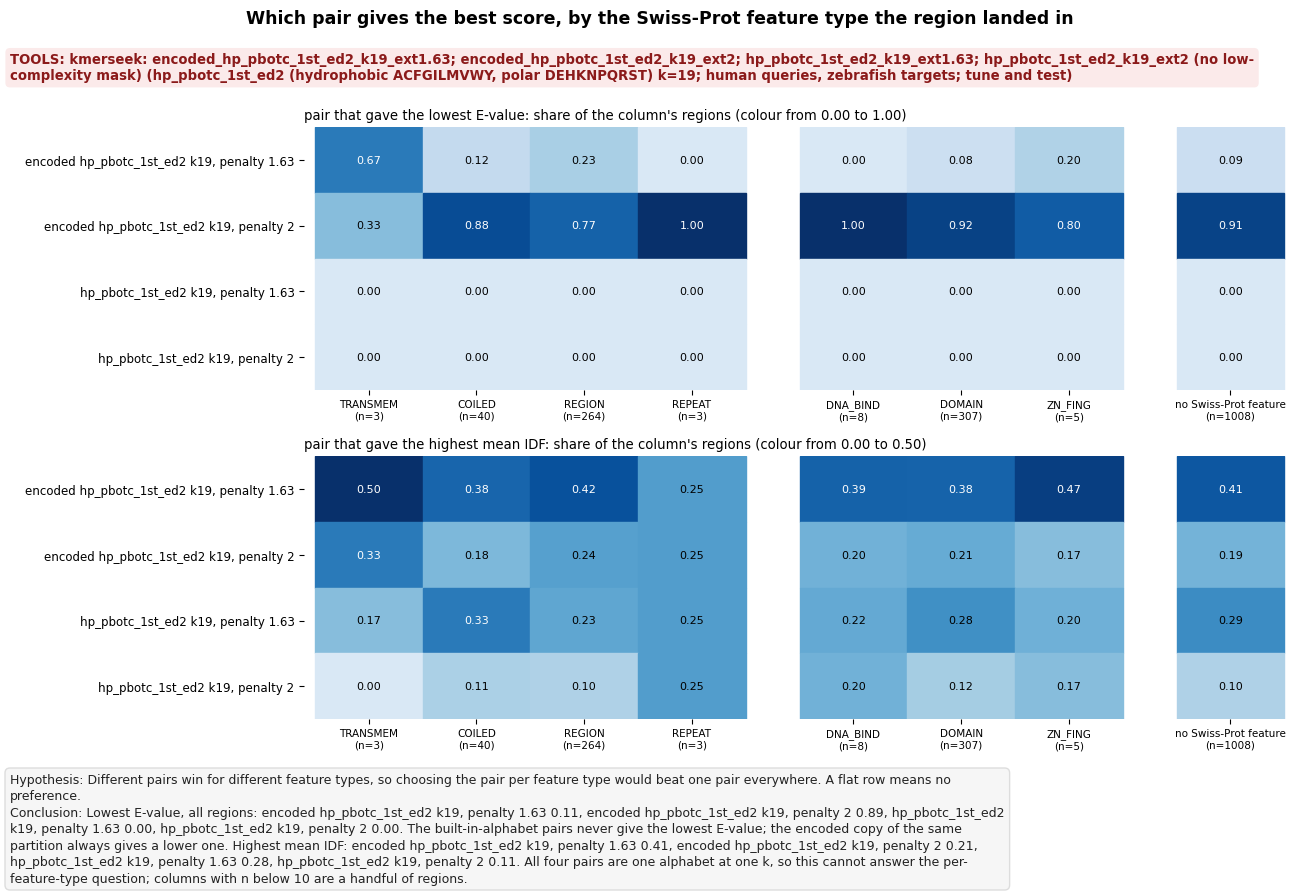

In [13]:
SHORT = {a: a.replace("encoded_", "encoded ").replace("_k19_ext", " k19, penalty ") for a in ARMS}
fig, axes = plt.subplots(2, 1, figsize=(13, 6.8))
cmap = plt.cm.Blues
for ax, (arms_col, name) in zip(axes, (("evalue_min_arms", "lowest E-value"), ("mean_idf_max_arms", "highest mean IDF"))):
    w_ = win[arms_col]
    xpos, x = [], 0
    for t in FT_ORDER:
        if t == (other[0] if other else NONE) or t == NONE:
            x += 0.5  # gap between groups
        xpos.append(x)
        x += 1
    M = np.array([[w_.filter((pl.col("arm") == a) & (pl.col("feature_type") == t))["share"][0] for t in FT_ORDER] for a in ARMS])
    vmin, vmax = float(M.min()), float(M.max())
    for i, a in enumerate(ARMS):
        for j, t in enumerate(FT_ORDER):
            ax.add_patch(plt.Rectangle((xpos[j] - 0.5, i - 0.5), 1, 1,
                                       color=cmap(0.15 + 0.85 * (M[i, j] - vmin) / max(vmax - vmin, 1e-9))))
            ax.text(xpos[j], i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if (M[i, j] - vmin) / max(vmax - vmin, 1e-9) > 0.6 else "black")
    ax.set_xlim(-0.6, xpos[-1] + 0.6)
    ax.set_ylim(len(ARMS) - 0.5, -0.5)
    ax.set_yticks(range(len(ARMS)), [SHORT[a] for a in ARMS], fontsize=8.5)
    ax.set_xticks(xpos, [f"{t}\n(n={n_ft.filter(pl.col('feature_type') == t)['len'][0]})" for t in FT_ORDER], fontsize=7.5)
    ax.set_title(f"pair that gave the {name}: share of the column's regions (colour from {vmin:.2f} to {vmax:.2f})",
                 fontsize=9.5, loc="left")
    for s in ax.spines.values():
        s.set_visible(False)
fig.tight_layout(rect=(0, 0, 1, 0.99))
spread = {k: v.group_by("arm").agg((pl.col("share").max() - pl.col("share").min()).alias("range")) for k, v in win.items()}
top = {k: v.group_by("feature_type").agg(pl.col("arm").sort_by("share").last()) for k, v in win.items()}
mu.finish_figure(
    fig, FIG / "262_best_of_n_winning_pair_by_swissprot_feature_type_zebrafish.png",
    tools=mu.tools_text(kmerseek=ARMS, lc=False,
                        note="hp_pbotc_1st_ed2 (hydrophobic ACFGILMVWY, polar DEHKNPQRST) k=19; human queries, zebrafish targets; tune and test"),
    title="Which pair gives the best score, by the Swiss-Prot feature type the region landed in",
    hypothesis="Different pairs win for different feature types, so choosing the pair per "
               "feature type would beat one pair everywhere. A flat row means no preference.",
    conclusion=("Lowest E-value, all regions: "
                + ", ".join(f"{SHORT[r['arm']]} {r['share']:.2f}" for r in overall["evalue_min_arms"].to_dicts())
                + ". The built-in-alphabet pairs never give the lowest E-value; the encoded copy of the "
                "same partition always gives a lower one. Highest mean IDF: "
                + ", ".join(f"{SHORT[r['arm']]} {r['share']:.2f}" for r in overall["mean_idf_max_arms"].to_dicts())
                + ". All four pairs are one alphabet at one k, so this cannot answer the per-feature-type "
                "question; columns with n below 10 are a handful of regions."),
    layout=False,
)

## Does the winning pair depend on region length?

The same winners plotted against each merged region's length, one point per region and
winning pair (a tied region appears on every tied pair's row, at reduced opacity). The
short tick on each row is that pair's median winning length. If one pair won on short
regions and another on long ones, the ticks would sit apart.

shape: (8, 6)
┌──────────────────┬──────────────────────────────────────┬───────────────┬──────────────────┬───────┬────────┐
│ score            ┆ arm                                  ┆ n_regions_won ┆ median_length_aa ┆ q25   ┆ q75    │
│ ---              ┆ ---                                  ┆ ---           ┆ ---              ┆ ---   ┆ ---    │
│ str              ┆ str                                  ┆ i64           ┆ f64              ┆ f64   ┆ f64    │
╞══════════════════╪══════════════════════════════════════╪═══════════════╪══════════════════╪═══════╪════════╡
│ lowest E-value   ┆ encoded_hp_pbotc_1st_ed2_k19_ext1.63 ┆ 185           ┆ 121.0            ┆ 95.0  ┆ 160.0  │
│ lowest E-value   ┆ encoded_hp_pbotc_1st_ed2_k19_ext2    ┆ 1528          ┆ 170.0            ┆ 98.0  ┆ 296.0  │
│ lowest E-value   ┆ hp_pbotc_1st_ed2_k19_ext1.63         ┆ 0             ┆ null             ┆ null  ┆ null   │
│ lowest E-value   ┆ hp_pbotc_1st_ed2_k19_ext2            ┆ 0             ┆ null          

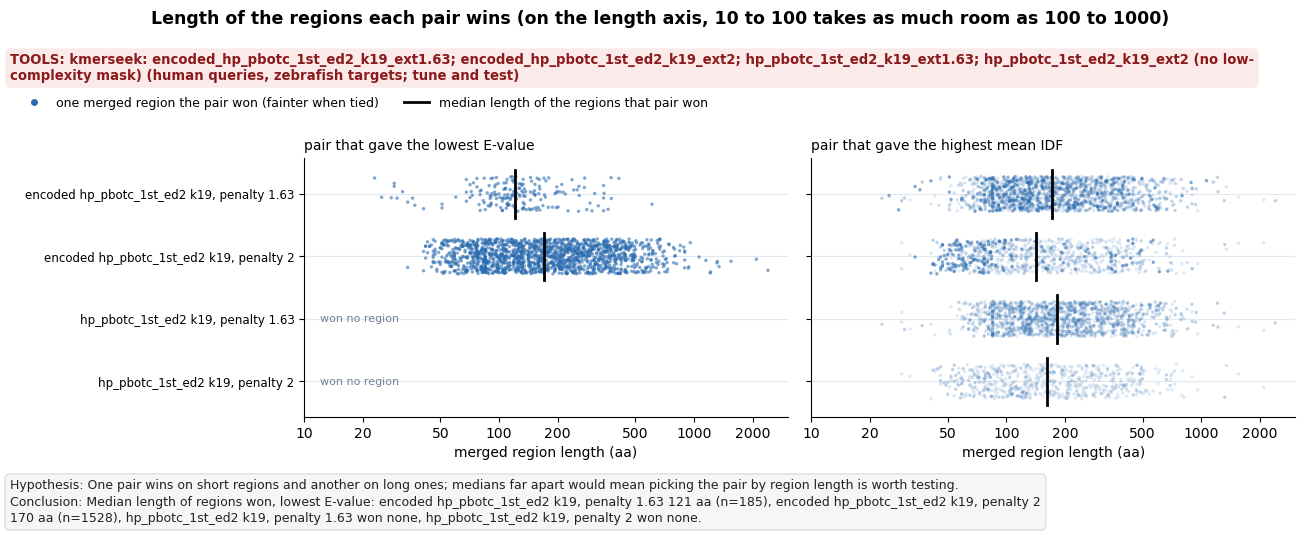

In [14]:
rng = np.random.default_rng(262)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.9), sharey=True)
len_rows = []
for ax, (arms_col, name) in zip(axes, (("evalue_min_arms", "lowest E-value"), ("mean_idf_max_arms", "highest mean IDF"))):
    long = scores.select("merged_length", arms_col).with_columns(k=pl.col(arms_col).list.len()).explode(arms_col)
    for i, a in enumerate(ARMS):
        sub = long.filter(pl.col(arms_col) == a)
        L = sub["merged_length"].to_numpy()
        if not len(L):
            ax.text(12, i, "won no region", va="center", fontsize=8, color="#718096")
            len_rows.append(dict(score=name, arm=a, n_regions_won=0, median_length_aa=None, q25=None, q75=None))
            continue
        alpha = np.clip(0.6 / sub["k"].to_numpy(), 0.1, 0.6)
        ax.scatter(L, i + rng.uniform(-0.28, 0.28, len(L)), s=6, color=BON_C, alpha=alpha, lw=0)
        med = float(np.median(L))
        ax.plot([med, med], [i - 0.38, i + 0.38], color="black", lw=2)
        len_rows.append(dict(score=name, arm=a, n_regions_won=len(L), median_length_aa=med,
                             q25=float(np.quantile(L, 0.25)) if len(L) else None,
                             q75=float(np.quantile(L, 0.75)) if len(L) else None))
    ax.set_xscale("log")
    ticks = [10, 20, 50, 100, 200, 500, 1000, 2000]
    ax.set_xticks(ticks, [str(t) for t in ticks])
    ax.minorticks_off()
    ax.set_xlabel("merged region length (aa)")
    ax.set_title(f"pair that gave the {name}", fontsize=10, loc="left")
    ax.set_yticks(range(len(ARMS)), [SHORT[a] for a in ARMS], fontsize=8.5)
    for i in range(len(ARMS)):
        ax.axhline(i, color="#E2E8F0", lw=0.8, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].invert_yaxis()
handles = [Line2D([], [], ls="none", marker="o", color=BON_C, ms=4),
           Line2D([], [], color="black", lw=2)]
fig.legend(handles, ["one merged region the pair won (fainter when tied)", "median length of the regions that pair won"],
           loc="upper left", bbox_to_anchor=(0.0, 1.0), ncol=2, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.9))
lt = pl.DataFrame(len_rows)
print(lt)
e = lt.filter(pl.col("score") == "lowest E-value")
mu.finish_figure(
    fig, FIG / "262_best_of_n_winning_pair_by_region_length_zebrafish.png",
    tools=mu.tools_text(kmerseek=ARMS, lc=False, note="human queries, zebrafish targets; tune and test"),
    title="Length of the regions each pair wins (on the length axis, 10 to 100 takes as much room as 100 to 1000)",
    hypothesis="One pair wins on short regions and another on long ones; medians far apart "
               "would mean picking the pair by region length is worth testing.",
    conclusion=("Median length of regions won, lowest E-value: "
                + ", ".join((f"{SHORT[r['arm']]} {r['median_length_aa']:.0f} aa (n={r['n_regions_won']})" if r["n_regions_won"] else f"{SHORT[r['arm']]} won none") for r in e.to_dicts())
                + "."),
    layout=False,
)

# Summary and Conclusions

## Background

Combiner B calls every merged kmerseek region any alphabet-ksize pair called and ranks it
by the best score any pair gave it: the lowest `region_evalue` (raw, and multiplied by the
number of pairs tried), or the highest `region_mean_idf`. This execution has four pairs,
all hp_pbotc_1st_ed2 at k=19 against zebrafish, and no shuffled-query run. It tests the
code and the procedure, not the gain from combining different alphabets. The numbers below
change when notebook 260 is rebuilt on the full run.

## Summary and Conclusions

* On tune, best of four pairs has average precision 0.033 on Swiss-Prot features and 0.172
  on Pfam domains, against 0.030 and 0.165 for the best single pair
  (encoded hp_pbotc_1st_ed2 k=19, penalty 2), ranked by the corrected E-value.
* The Kyte-Doolittle scan, which searches nothing, has tune average precision 0.109 on
  Swiss-Prot, three times best of four pairs. On Pfam it has the higher precision (0.685
  against 0.550) and lower recall (0.118 against 0.343), so lower average precision, 0.067.
* Ranked by E-value, best of four pairs never reaches Swiss-Prot precision 0.5 on tune
  (highest 0.409). On Pfam every region in the table passes: the frozen threshold is a
  corrected E-value of 39.9, a raw 9.97, which keeps all 891 tune regions at precision
  0.550 and recall 0.343.
* The correction multiplies every zebrafish region by 4, so it changes the number of calls
  at a fixed cut, not the order: at an E-value cut of 1, 673 tune regions by the raw value
  and 629 by the corrected one; at 10, 891 and 719.
* On test at the frozen threshold, best of four pairs calls 822 regions with Swiss-Prot
  precision 0.359 and recall 0.076, Pfam precision 0.543 and recall 0.320. The single pair
  calls 795 (0.354, 0.073, 0.543, 0.312) and combiner A's two-pair panel 720 (0.341, 0.063,
  0.547, 0.291).
* No shuffled-query table exists, so there is no false-call rate per query yet.
* On 241 test queries with at least two Pfam domains, best of four pairs lands in a mean of
  0.78 domains per query, the single pair 0.76, combiner A 0.68 and phmmer 2.71. Best of
  four pairs lands no domain on 98 of the 241 queries; phmmer on 18.
* The encoded copy of the partition gives the lowest E-value in every one of the 1_713
  regions (penalty 2 in 89.2%, penalty 1.63 in 10.8%); the built-in-alphabet searches never
  do. The highest mean IDF is tied between two or more pairs in 1_368 of the 1_713 regions.

## Analysis Details

The three ranking scores give the same picture here. The four pairs are one search at two
extension penalties, run two ways, so the best of four sits on top of the single pair's
curve and adds 5% more regions (891 against 847 on tune). The question this notebook
is built for, whether a pair from a different alphabet supplies regions the others miss,
needs the full run.

Pfam precision stays between 0.53 and 0.57 at every raw E-value cut from 0.000001 to 10,
so the precision 0.5 rule keeps every region the table holds. Notebook 260 kept only calls
with `region_evalue` < 10; a looser cut might still hold precision 0.5, and this execution
cannot see it.

The Kyte-Doolittle scan scores higher on Swiss-Prot than kmerseek for the reason
[notebook 231](231_swissprot_composition_controls.ipynb) found: the scan marks
transmembrane helices, and TRANSMEM is one of the Swiss-Prot feature types. On Pfam the
scan also has the higher precision (0.685 on tune, against 0.550 for best of four pairs at
the frozen threshold), but it finds 0.118 of the Pfam domains against 0.343, so its average
precision is lower.

The heatmap of winning pairs is the figure the per-feature-type question needs. With four
near-copies, the E-value winner is set by encoding (encoded always lower) and then by
penalty, and the regions the penalty-1.63 search wins are shorter (median 121 aa, n=185)
than those penalty 2 wins (median 170 aa, n=1_528). Several feature-type columns hold
fewer than 10 regions.

## Supplementary Information

- Input: `~/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet`
  (6_140 rows; sha256 in `262_best_of_n_threshold.yaml`) and the `reduced/` call files
  (318_268 calls), from notebook 260 on PR #88.
- Truth: `human_domain_truth.parquet` (Pfam) and `human_swissprot_truth.parquet`
  (Swiss-Prot) under the midi-plus run directory.
- Query sequences: QfO 2020_04 human proteome, `UP000005640_9606.fasta`, as notebook 231.
- phmmer: `regions/hmmer3_phmmer/human_vs_zebrafish.hmmer3_phmmer.tsv.gz`, midi-plus region
  benchmark (1-2 Sept 2026), i-Evalue per domain.
- Combiner A: `261_intersection_panel.yaml`, checked to have read the same table.
- Code: `notebooks/region_combiner_262.py`, `notebooks/262_build_notebook.py`.
- To rebuild on the full run: run `make run-midi-plus-0.4-extend` and the `M04_RUN=decoy`
  twin, reduce both with notebook 260's code (the shuffled-query files into
  `260_region_table/reduced_decoy/`), then re-execute notebooks 261 and 262.

## References

- [Notebook 260](260_kmerseek_region_table.ipynb): the region table this notebook reads.
- [Notebook 261](261_combiner_a_intersection_panel.ipynb): combiner A.
- [Notebook 231](231_swissprot_composition_controls.ipynb): the Kyte-Doolittle control.
- Kyte, J., and R. F. Doolittle. "A Simple Method for Displaying the Hydropathic Character
  of a Protein." *Journal of Molecular Biology* 157, no. 1 (1982): 105-32. DOI still needs
  checking.

In [15]:
summary_md = r"""
# Summary and Conclusions

## Background

Combiner B calls every merged kmerseek region any alphabet-ksize pair called and ranks it
by the best score any pair gave it: the lowest `region_evalue` (raw, and multiplied by the
number of pairs tried), or the highest `region_mean_idf`. This execution has four pairs,
all hp_pbotc_1st_ed2 at k=19 against zebrafish, and no shuffled-query run. It tests the
code and the procedure, not the gain from combining different alphabets. The numbers below
change when notebook 260 is rebuilt on the full run.

## Summary and Conclusions

* On tune, best of four pairs has average precision 0.033 on Swiss-Prot features and 0.172
  on Pfam domains, against 0.030 and 0.165 for the best single pair
  (encoded hp_pbotc_1st_ed2 k=19, penalty 2), ranked by the corrected E-value.
* The Kyte-Doolittle scan, which searches nothing, has tune average precision 0.109 on
  Swiss-Prot, three times best of four pairs. On Pfam it has the higher precision (0.685
  against 0.550) and lower recall (0.118 against 0.343), so lower average precision, 0.067.
* Ranked by E-value, best of four pairs never reaches Swiss-Prot precision 0.5 on tune
  (highest 0.409). On Pfam every region in the table passes: the frozen threshold is a
  corrected E-value of 39.9, a raw 9.97, which keeps all 891 tune regions at precision
  0.550 and recall 0.343.
* The correction multiplies every zebrafish region by 4, so it changes the number of calls
  at a fixed cut, not the order: at an E-value cut of 1, 673 tune regions by the raw value
  and 629 by the corrected one; at 10, 891 and 719.
* On test at the frozen threshold, best of four pairs calls 822 regions with Swiss-Prot
  precision 0.359 and recall 0.076, Pfam precision 0.543 and recall 0.320. The single pair
  calls 795 (0.354, 0.073, 0.543, 0.312) and combiner A's two-pair panel 720 (0.341, 0.063,
  0.547, 0.291).
* No shuffled-query table exists, so there is no false-call rate per query yet.
* On 241 test queries with at least two Pfam domains, best of four pairs lands in a mean of
  0.78 domains per query, the single pair 0.76, combiner A 0.68 and phmmer 2.71. Best of
  four pairs lands no domain on 98 of the 241 queries; phmmer on 18.
* The encoded copy of the partition gives the lowest E-value in every one of the 1_713
  regions (penalty 2 in 89.2%, penalty 1.63 in 10.8%); the built-in-alphabet searches never
  do. The highest mean IDF is tied between two or more pairs in 1_368 of the 1_713 regions.

## Analysis Details

The three ranking scores give the same picture here. The four pairs are one search at two
extension penalties, run two ways, so the best of four sits on top of the single pair's
curve and adds 5% more regions (891 against 847 on tune). The question this notebook
is built for, whether a pair from a different alphabet supplies regions the others miss,
needs the full run.

Pfam precision stays between 0.53 and 0.57 at every raw E-value cut from 0.000001 to 10,
so the precision 0.5 rule keeps every region the table holds. Notebook 260 kept only calls
with `region_evalue` < 10; a looser cut might still hold precision 0.5, and this execution
cannot see it.

The Kyte-Doolittle scan scores higher on Swiss-Prot than kmerseek for the reason
[notebook 231](231_swissprot_composition_controls.ipynb) found: the scan marks
transmembrane helices, and TRANSMEM is one of the Swiss-Prot feature types. On Pfam the
scan also has the higher precision (0.685 on tune, against 0.550 for best of four pairs at
the frozen threshold), but it finds 0.118 of the Pfam domains against 0.343, so its average
precision is lower.

The heatmap of winning pairs is the figure the per-feature-type question needs. With four
near-copies, the E-value winner is set by encoding (encoded always lower) and then by
penalty, and the regions the penalty-1.63 search wins are shorter (median 121 aa, n=185)
than those penalty 2 wins (median 170 aa, n=1_528). Several feature-type columns hold
fewer than 10 regions.

## Supplementary Information

- Input: `~/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet`
  (6_140 rows; sha256 in `262_best_of_n_threshold.yaml`) and the `reduced/` call files
  (318_268 calls), from notebook 260 on PR #88.
- Truth: `human_domain_truth.parquet` (Pfam) and `human_swissprot_truth.parquet`
  (Swiss-Prot) under the midi-plus run directory.
- Query sequences: QfO 2020_04 human proteome, `UP000005640_9606.fasta`, as notebook 231.
- phmmer: `regions/hmmer3_phmmer/human_vs_zebrafish.hmmer3_phmmer.tsv.gz`, midi-plus region
  benchmark (1-2 Sept 2026), i-Evalue per domain.
- Combiner A: `261_intersection_panel.yaml`, checked to have read the same table.
- Code: `notebooks/region_combiner_262.py`, `notebooks/262_build_notebook.py`.
- To rebuild on the full run: run `make run-midi-plus-0.4-extend` and the `M04_RUN=decoy`
  twin, reduce both with notebook 260's code (the shuffled-query files into
  `260_region_table/reduced_decoy/`), then re-execute notebooks 261 and 262.

## References

- [Notebook 260](260_kmerseek_region_table.ipynb): the region table this notebook reads.
- [Notebook 261](261_combiner_a_intersection_panel.ipynb): combiner A.
- [Notebook 231](231_swissprot_composition_controls.ipynb): the Kyte-Doolittle control.
- Kyte, J., and R. F. Doolittle. "A Simple Method for Displaying the Hydropathic Character
  of a Protein." *Journal of Molecular Biology* 157, no. 1 (1982): 105-32. DOI still needs
  checking.
"""
print(summary_md)


# Summary and Conclusions

## Background

Combiner B calls every merged kmerseek region any alphabet-ksize pair called and ranks it
by the best score any pair gave it: the lowest `region_evalue` (raw, and multiplied by the
number of pairs tried), or the highest `region_mean_idf`. This execution has four pairs,
all hp_pbotc_1st_ed2 at k=19 against zebrafish, and no shuffled-query run. It tests the
code and the procedure, not the gain from combining different alphabets. The numbers below
change when notebook 260 is rebuilt on the full run.

## Summary and Conclusions

* On tune, best of four pairs has average precision 0.033 on Swiss-Prot features and 0.172
  on Pfam domains, against 0.030 and 0.165 for the best single pair
  (encoded hp_pbotc_1st_ed2 k=19, penalty 2), ranked by the corrected E-value.
* The Kyte-Doolittle scan, which searches nothing, has tune average precision 0.109 on
  Swiss-Prot, three times best of four pairs. On Pfam it has the higher precision (0.685
  against 0.